ARTI406 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

In this notebook, we will apply practical preprocessing techniques step by step using the **Car Details from Car Dekho** dataset.


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
print("✔ Libraries imported successfully")


✔ Libraries imported successfully


## 1. Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("CAR_DETAILS_FROM_CAR_DEKHO.csv")
df.head(10)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `year` should be a proper integer representing the manufacturing year
- `selling_price` and `km_driven` should be numeric
- `fuel`, `seller_type`, `transmission`, and `owner` are categorical


In [3]:
df.dtypes

name               str
year             int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object

We observe that:
- `selling_price` and `km_driven` are stored as *int64* ✔
- `year` is stored as *int64* ✔
- `name`, `fuel`, `seller_type`, `transmission`, `owner` are *object* (categorical) ✔

All columns appear to be in reasonable types. However, we will inspect the values more carefully for hidden issues such as duplicates and outliers.


### 2.2 Descriptive Statistics
Descriptive statistics help us understand the distribution of each numerical column and spot potential issues.


In [4]:
df.describe().round(2)

,year,selling_price,km_driven
count,4340.00,4340.00,4340.00
mean,2013.09,504127.31,66215.78
std,4.22,578548.74,46644.10
min,1992.00,20000.00,1.00
25%,2011.00,208749.75,35000.00
50%,2014.00,350000.00,60000.00
75%,2016.00,600000.00,90000.00
max,2020.00,8900000.00,806599.00


From the statistics above, we notice:
- `km_driven` has a **minimum of 1** — this is suspiciously low and likely a data entry error.
- `selling_price` has a **maximum of 8,900,000 INR** — this is much higher than the 75th percentile (600,000), indicating possible outliers.
- `year` ranges from **1992 to 2020** — very old cars may be classic collectibles or errors.


### 2.3 Check Missing Values
Missing values reduce data quality and can negatively affect model performance.


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})


,Missing Count,Missing %
name,0,0.0
year,0,0.0
selling_price,0,0.0
km_driven,0,0.0
fuel,0,0.0
seller_type,0,0.0
transmission,0,0.0
owner,0,0.0


The output shows whether any column contains missing values.
If all values are zero, the dataset has no missing entries in its original form.


### 2.4 Check Duplicate Rows
Duplicate records can bias the model by giving extra weight to repeated observations.


In [6]:
n_dups = df.duplicated().sum()
print(f"Duplicate rows found: {n_dups}")


Duplicate rows found: 763


The dataset contains duplicate rows. These must be removed before further analysis to ensure data integrity.


### 2.5 Categorical Column Distributions
Understanding the distribution of categorical values helps detect imbalances or unexpected entries.


In [7]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in cat_cols:
    print(f"── {col} ──")
    print(df[col].value_counts().to_string())
    print()


── fuel ──
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1

── seller_type ──
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102

── transmission ──
transmission
Manual       3892
Automatic     448

── owner ──
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17



We observe:
- `fuel`: Most cars run on **Petrol** or **Diesel**. Electric and LPG are rare.
- `seller_type`: Majority are **Individual** sellers.
- `transmission`: **Manual** transmission dominates.
- `owner`: Most cars have **First Owner** history.


### 2.6 Visualize Distributions


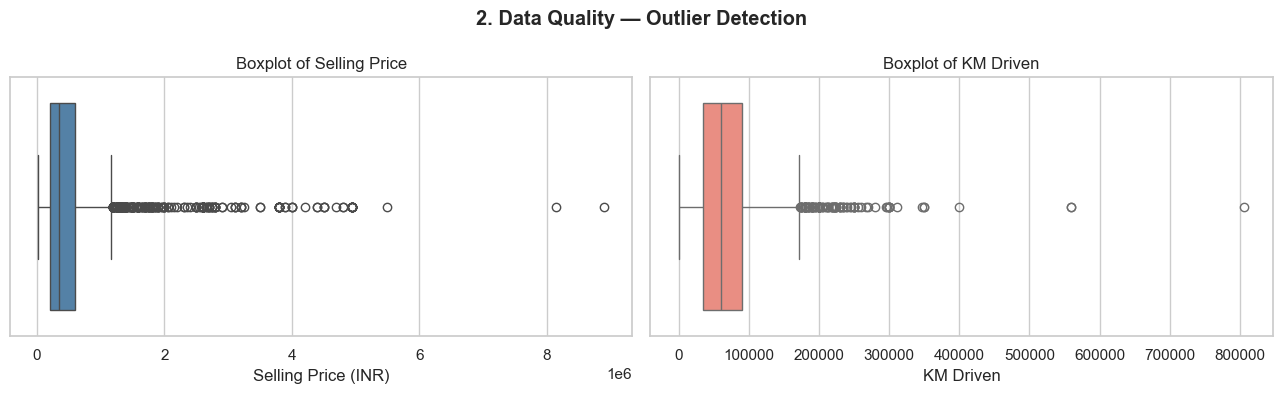

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Selling price boxplot
sns.boxplot(x=df['selling_price'], ax=axes[0], color='steelblue')
axes[0].set_title("Boxplot of Selling Price")
axes[0].set_xlabel("Selling Price (INR)")

# KM driven boxplot
sns.boxplot(x=df['km_driven'], ax=axes[1], color='salmon')
axes[1].set_title("Boxplot of KM Driven")
axes[1].set_xlabel("KM Driven")

plt.suptitle("2. Data Quality — Outlier Detection", fontweight='bold')
plt.tight_layout()
plt.show()


Points outside the whiskers represent **potential outliers**.
Extreme values in `selling_price` and `km_driven` are clearly visible and will be handled in Task 3.


## 3. Handling Missing Values
### 3.1 Detect Missing Values


In [9]:
df.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

The output confirms the missing values count per column.
Since the original dataset has no missing values, we will introduce artificial ones for learning purposes — then demonstrate how to handle them.


### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.

We will run this:

`df_missing.loc[0:5, 'selling_price'] = np.nan`

- `df_missing`: A copy of the DataFrame we are modifying.
- `.loc[0:5, 'selling_price']`: Selects rows 0 through 5 in the `selling_price` column.
- `= np.nan`: Assigns missing values to those positions.


In [10]:
df_missing = df.copy()
df_missing.loc[0:5, 'selling_price'] = np.nan
df_missing.loc[10:14, 'km_driven']   = np.nan

print("Missing values after injection:")
print(df_missing.isna().sum())


Missing values after injection:
name             0
year             0
selling_price    6
km_driven        5
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


Now the `selling_price` and `km_driven` columns contain missing values.

In [11]:
print("Original shape  :", df.shape)
print("After injection :", df_missing.shape)


Original shape  : (4340, 8)
After injection : (4340, 8)


In [12]:
df_missing.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,NaN,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,NaN,50000.0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,NaN,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,NaN,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,NaN,141000.0,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,NaN,125000.0,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000.0,25000.0,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000.0,60000.0,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000.0,25000.0,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000.0,78000.0,CNG,Individual,Manual,First Owner


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.


In [13]:
df_removed = df_missing.dropna()
df_removed.shape


(4329, 8)

In [14]:
df_removed.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.


### Strategy 2: Mean Imputation

The mean represents the average value.
It is commonly used for normally distributed data without extreme outliers.


In [15]:
df_imputed_mean = df_missing.copy()

mean_sp = df_imputed_mean['selling_price'].mean()
df_imputed_mean['selling_price'] = df_imputed_mean['selling_price'].fillna(mean_sp)

mean_km = df_imputed_mean['km_driven'].mean()
df_imputed_mean['km_driven'] = df_imputed_mean['km_driven'].fillna(mean_km)

df_imputed_mean.isna().sum()


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [16]:
df_imputed_mean.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,504447.977157,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,504447.977157,50000.0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,504447.977157,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,504447.977157,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,504447.977157,141000.0,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,504447.977157,125000.0,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000.000000,25000.0,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000.000000,60000.0,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000.000000,25000.0,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000.000000,78000.0,CNG,Individual,Manual,First Owner


Missing values are now replaced with the average.
This preserves dataset size but may introduce bias when outliers are present — as is the case here.
Mean imputation is sensitive to outliers.


### Strategy 3: Median Imputation

The median is more robust to outliers than the mean.
It is preferred for skewed data — like selling price or km driven in a used car dataset.


In [17]:
df_imputed_median = df_missing.copy()

median_sp = df_imputed_median['selling_price'].median()
df_imputed_median['selling_price'] = df_imputed_median['selling_price'].fillna(median_sp)

median_km = df_imputed_median['km_driven'].median()
df_imputed_median['km_driven'] = df_imputed_median['km_driven'].fillna(median_km)

df_imputed_median.isna().sum()


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [18]:
df_imputed_median.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,350000.0,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,350000.0,50000.0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,350000.0,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,350000.0,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,350000.0,141000.0,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,350000.0,125000.0,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000.0,25000.0,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000.0,60000.0,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000.0,25000.0,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000.0,78000.0,CNG,Individual,Manual,First Owner


Missing values are replaced with the **middle value**.
This approach is safer when data contains extreme values, making it the preferred strategy for this dataset.


## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the **IQR method**.


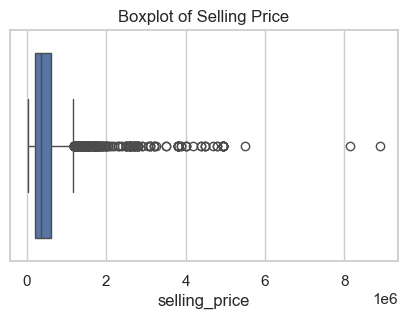

In [19]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=df['selling_price'])
plt.title("Boxplot of Selling Price")
plt.show()


Points outside the whiskers represent potential outliers.
Extreme selling price values may correspond to luxury cars or data entry errors.


### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`


In [20]:
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1     : {Q1:,.0f}")
print(f"Q3     : {Q3:,.0f}")
print(f"IQR    : {IQR:,.0f}")
print(f"Lower  : {lower:,.0f}")
print(f"Upper  : {upper:,.0f}")

outliers = df[(df['selling_price'] < lower) | (df['selling_price'] > upper)]
print(f"\nOutliers detected: {len(outliers)}")
outliers.head(10)


Q1     : 208,750
Q3     : 600,000
IQR    : 391,250
Lower  : -378,126
Upper  : 1,186,875

Outliers detected: 271


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
12,Toyota Corolla Altis 1.8 VL CVT,2018,1650000,25000,Petrol,Dealer,Automatic,First Owner
25,Toyota Corolla Altis 1.8 VL CVT,2018,1650000,25000,Petrol,Dealer,Automatic,First Owner
27,Hyundai Venue SX Opt Diesel,2019,1195000,5000,Diesel,Dealer,Manual,First Owner
29,Jaguar XF 2.2 Litre Luxury,2014,1964999,28000,Diesel,Dealer,Automatic,First Owner
30,Mercedes-Benz New C-Class 220 CDI AT,2013,1425000,59000,Diesel,Dealer,Automatic,First Owner
32,Audi Q5 2.0 TDI,2011,1190000,175900,Diesel,Dealer,Automatic,First Owner
35,Audi A6 2.0 TDI Design Edition,2013,1735000,50000,Diesel,Dealer,Automatic,First Owner
36,Mercedes-Benz New C-Class C 220 CDI Avantgarde,2012,1375000,33800,Diesel,Dealer,Automatic,Second Owner
39,Toyota Innova 2.5 G (Diesel) 7 Seater,2015,1300000,80000,Diesel,Individual,Manual,First Owner
40,Jeep Compass 1.4 Sport Plus BSIV,2019,1400000,10000,Petrol,Individual,Manual,First Owner


The output displays records considered extreme based on statistical boundaries.
These may be valid luxury car listings or potential data errors.


### Remove Outliers
We remove values outside the acceptable range.

In [21]:
df_no_outliers = df[(df['selling_price'] >= lower) & (df['selling_price'] <= upper)].copy()
print("Original shape        :", df.shape)
print("After removing outliers:", df_no_outliers.shape)


Original shape        : (4340, 8)
After removing outliers: (4069, 8)


The dataset size is reduced after removing outliers.
This helps prevent extreme values from dominating model training.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but real events.
For example, in a used car dataset, a very high selling price might correspond to a rare luxury or vintage car.

Before removing outliers, we should always ask:
- Is this a data entry mistake?
- Or is it a valid but rare observation?


### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

In [22]:
lower_cap = df['selling_price'].quantile(0.05)
upper_cap = df['selling_price'].quantile(0.95)

df_capped = df.copy()
df_capped['selling_price'] = df_capped['selling_price'].clip(lower_cap, upper_cap)

print(f"Lower cap (5th percentile) : {lower_cap:,.0f}")
print(f"Upper cap (95th percentile): {upper_cap:,.0f}")
print("\nAfter capping:")
df_capped['selling_price'].describe().round(2)


Lower cap (5th percentile) : 80,000
Upper cap (95th percentile): 1,300,000

After capping:


count       4340.00
mean      449009.50
std       322645.85
min        80000.00
25%       208749.75
50%       350000.00
75%       600000.00
max      1300000.00
Name: selling_price, dtype: float64

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range between 0 and 1.

**Formula:**

`x' = (x - x_min) / (x_max - x_min)`

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means Clustering
- Neural Networks


In [23]:
df_no_outliers[['selling_price', 'km_driven', 'year']].head()

,selling_price,km_driven,year
0,60000,70000,2007
1,135000,50000,2007
2,600000,100000,2012
3,250000,46000,2017
4,450000,141000,2014


In [24]:
scaler_mm = MinMaxScaler()
df_scaled = df_no_outliers[['selling_price', 'km_driven', 'year']].copy()

df_scaled[['selling_price', 'km_driven', 'year']] = scaler_mm.fit_transform(df_scaled)

print("Min-Max Scaled Statistics:")
print(df_scaled.describe().loc[['min','max','mean']].round(4))
df_scaled.head()


Min-Max Scaled Statistics:
      selling_price  km_driven    year
min          0.0000     0.0000  0.0000
max          1.0000     1.0000  1.0000
mean         0.3252     0.0837  0.7458


,selling_price,km_driven,year
0,0.034934,0.086783,0.535714
1,0.100437,0.061988,0.535714
2,0.506550,0.123976,0.714286
3,0.200873,0.057028,0.892857
4,0.375546,0.174807,0.785714


After applying Min-Max normalization, all numerical values are scaled to the range [0, 1].

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does **NOT** change the relative relationships between data points.
If one car originally had a higher price than another, it will still have a higher normalized value.


### Z-Score Normalization
Z-score standardization transforms the data so that:
- The **mean** of each feature becomes 0
- The **standard deviation** becomes 1

**Formula:**

`x' = (x - μ) / σ`

This method keeps the shape of the distribution but rescales it around zero.


In [25]:
scaler_z = StandardScaler()
df_standardized = df_no_outliers[['selling_price', 'km_driven', 'year']].copy()

df_standardized[['selling_price', 'km_driven', 'year']] = scaler_z.fit_transform(df_standardized)

print("Z-Score Standardized Statistics:")
print(df_standardized.describe().loc[['mean','std','min','max']].round(4))
df_standardized.head()


Z-Score Standardized Statistics:
      selling_price  km_driven    year
mean         0.0000     0.0000 -0.0000
std          1.0001     1.0001  1.0001
min         -1.5010    -1.4376 -4.9453
max          3.1144    15.7416  1.6857


,selling_price,km_driven,year
0,-1.339792,0.053275,-1.392992
1,-1.037473,-0.372692,-1.392992
2,0.836905,0.692227,-0.208885
3,-0.573917,-0.457886,0.975222
4,0.232267,1.565461,0.264758


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below become **negative**.

This transformation is especially useful for:
- Linear Regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.


## Check Correlation Before Applying PCA

We will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship
- **Correlation close to -1** → Strong negative linear relationship
- **Correlation close to 0**  → Weak or no linear relationship

In such cases, dimensionality reduction using PCA can be beneficial.


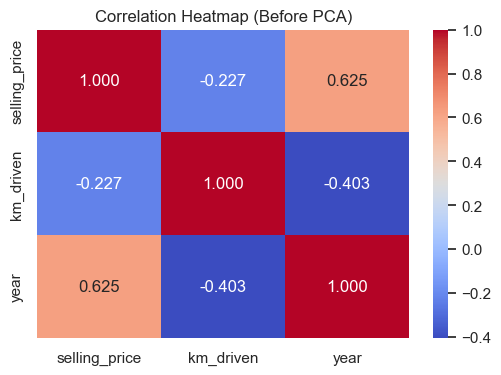

In [26]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_standardized[['selling_price', 'km_driven', 'year']].corr(),
            annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Correlation Heatmap (Before PCA)")
plt.show()


The heatmap shows the correlation between our numerical features.

- `year` and `selling_price` show a **positive correlation** — newer cars tend to sell for higher prices.
- `km_driven` and `selling_price` show a **negative correlation** — cars with more mileage sell for less.
- `km_driven` and `year` show a **negative correlation** — older cars have been driven more.

Since correlations exist between features, PCA can effectively reduce dimensionality while retaining most of the information.


## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:
- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.
The second (PC2) captures the next largest variance, while being perpendicular to PC1.


### Visual Intuition

Imagine we have three features: `selling_price`, `km_driven`, and `year`.

PCA finds new axes (directions) in this 3D space that best summarize the spread of data points.

Instead of keeping all 3 correlated features separately, PCA combines them into fewer components — preserving most of the useful information while reducing complexity.


In [27]:
X = df_standardized[['selling_price', 'km_driven', 'year']].values

pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_.round(4))
print(f"\nPC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"PC3: {pca.explained_variance_ratio_[2]*100:.2f}%")
print(f"\nCumulative (PC1+PC2): {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")


Explained Variance Ratio: [0.6197 0.2657 0.1146]

PC1: 61.97%
PC2: 26.57%
PC3: 11.46%

Cumulative (PC1+PC2): 88.54%


The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

- If PC1 and PC2 together explain a high percentage (e.g. >85%), we can safely represent our data in 2 dimensions instead of 3.
- This simplifies models, reduces computational cost, and can improve generalization.


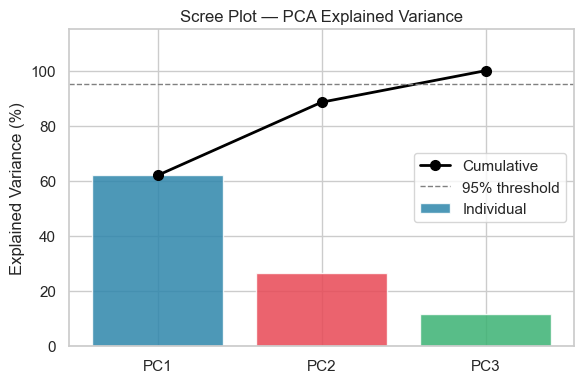

In [28]:
# Scree Plot
plt.figure(figsize=(6, 4))
pc_labels = ['PC1', 'PC2', 'PC3']
cumulative = np.cumsum(pca.explained_variance_ratio_)

plt.bar(pc_labels, pca.explained_variance_ratio_ * 100,
        color=['#2E86AB', '#E84855', '#3BB273'], alpha=0.85, label='Individual')
plt.plot(pc_labels, cumulative * 100, 'o-', color='black',
         linewidth=2, markersize=7, label='Cumulative')
plt.axhline(y=95, color='gray', linestyle='--', linewidth=1, label='95% threshold')
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot — PCA Explained Variance")
plt.legend()
plt.ylim(0, 115)
plt.tight_layout()
plt.show()


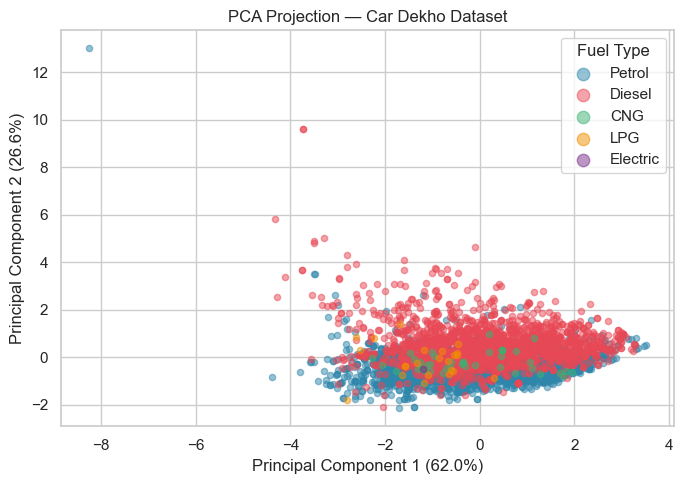

In [29]:
# PCA 2D Scatter — colored by fuel type
plt.figure(figsize=(7, 5))
fuel_types   = df_no_outliers['fuel'].values
unique_fuels = df_no_outliers['fuel'].unique()
colors = ['#2E86AB', '#E84855', '#3BB273', '#F18F01', '#7B2D8B']

for i, fuel in enumerate(unique_fuels):
    mask = fuel_types == fuel
    plt.scatter(principal_components[mask, 0], principal_components[mask, 1],
                label=fuel, alpha=0.5, s=20, color=colors[i % len(colors)])

plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA Projection — Car Dekho Dataset")
plt.legend(title='Fuel Type', markerscale=2)
plt.tight_layout()
plt.show()


Each point in this plot represents one car listing.

The axes no longer represent the original features (`selling_price`, `km_driven`, `year`).
Instead:

- The horizontal axis represents **Principal Component 1 (PC1)** — the direction of maximum variance.
- The vertical axis represents **Principal Component 2 (PC2)** — the second most important direction.

The spread of points along the horizontal direction indicates how much variation is captured by PC1.
Points colored by fuel type show whether PCA separates different fuel categories in the projected space.


---
# Assignment

In this assignment, you will:
- **Task 1** Identify data quality issues in the dataset.
- **Task 2** Apply one missing value strategy and explain why.
- **Task 3** Detect and handle outliers using IQR.
- **Task 4** Normalize numerical features using both Min-Max and Z-score.
- **Task 5** Apply PCA and interpret explained variance.

End of Assignment 2
